# Part 1

The code below

(0.0, 1.0)

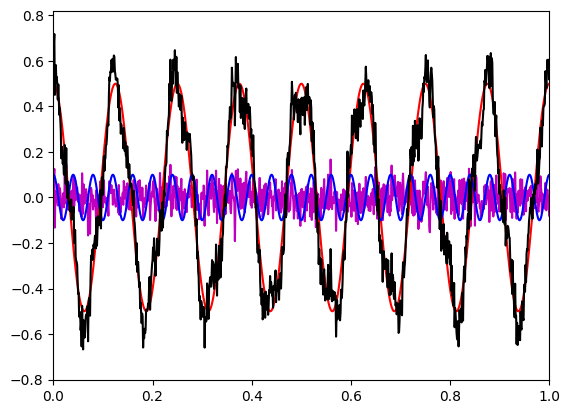

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

time = np.arange(0,100,0.001)
sig1 = 0.5*np.cos(time*2*np.pi*8)
sig2 = 0.1*np.cos(time*2*np.pi*25)
noise = 0.05*np.random.randn(time.shape[0])

sig3 = sig1+sig2+noise
plt.plot(time, noise,'m')
plt.plot(time, sig1,'r')
plt.plot(time, sig2,'b')
plt.plot(time, sig3,'k')
plt.xlim((0,1))



In [ ]:
def filter(signal, f_low, f_high):

  return signal







## Exercise 1:

Use the filter function above to filter two components present in signal: one from 5 to 10 Hz, and another from 20 to 40.

Plot the two components in a new plot. Also plot the difference between the original sig1 and sig2 with their respective components.

## Exercise 2:

Use the functions np.mean and np.std to calculate the average (μ) of and standard deviation (σ) of the synthetic signal generated (sig3). Use that to define a threshold of μ + 2*σ

Plot the signal (in black) and the threshold (as a dashed line). In addition to that, replot all the signal traces that are above the threshold (as disconected dots in red)

Limit your plot to the first 1 second.

# Part 2

The functions `np.where` can be very useful to find indices of an array that fulfill certain conditions. For example, look at the code below:
```
arr = np.array([1,2,3,5,5,7,10])

indices = np.where(arr==5)
```
The variable `indices` is the tuple `(array([3, 4]), )` in which the first element is an array with the indices of `arr` in which the condition `arr==5` is True.

This means we can use indices to access all the elements of arr that fulfill the condition:

`arr[indices[0]]`

One might ask, how is this different than `arr[arr==5]`? It is true that they result in the same operation. However, sometimes one needs to do operations in the indices themselves. For example, imagine that you have a signal and want to get periods in which the signal is higher than a threshold for 3 consecutive points.

You could do something like `signal[signal>threshold]` to get the values above the threshold, but that does not guarantee that you will have consecutive activation. Instead, if you use np.where, you can find the indices where the condition is True.

idx = np.where(signal>threshold)[0]

Imagine that the resulting vector is something like:
`[2,3, 10,11,12, 21,22,23,24,25, 30]`

By looking at it, we can see four periods in which the signal was above the threshold: 2-3, 10-12, 21-25 and 30 (also shown in the spacing used). Only two of them fullfill our criteria of three consecutive points (10-12 and 21-25). Let's see how we can get this information from the code:

if we do the operation `diff = idx[1:]-idx[:-1]` we are basically creating a new array in which each value is the difference between two consecutive values of our idx array (e.g., diff[0] is idx[1]-idx[0]; diff[1] is idx[2]-idx[1], and so on). Note that this new array diff has one less element then idx (because there is no previous value to subtract from the first element). In our example, diff would be:

`[1,7,1,1,9,1,1,1,1,5]`

Note that whenever diff is different than 1, this represents a two points that are not consecutive. We could then use np.where to find all the transition points between two activation periods by doing something like:

transitions = np.where(diff>1)[0]

Now we would have transitions as the array:
`[1,4,9]`

Which will always be the length of the amount of contiguous periods that we have minus one (4-1 in this case). We now know where in idx is the beginning and end of a contiguous period:

The first period goes from idx[0] to idx[transition[0]] (2-3)
The second period goes from idx[transition[0]+1] to idx[transition[1]] (10-12)
The third period goes from idx[transition[1]+1] to idx[transition[2]] (21,25)
and we can build a last period from idx[transition[2]+1] until the end of the array: idx[transition[2]+1] to idx[-1]

So we can build an array with the starting indices of the contiguous periods:
`start = np.concatenate([[idx[0]], idx[transition+1]])`
And similarly the ending indices:
`end = np.concat([idx[transition], [idx[-1]]])`

Note that we added idx[0] and idx[-1] because even thought these points are part of a contiguous period, they are not captured by the transitions, since there is nothing before or after them.

Now we have:
start = [2, 10, 21, 30]
end =   [3, 12, 25, 30]

Where start[0] corresponds to the start of the first threshold activation. And end[0] corresponds to the end of such activation. We can simply do `duration = end-start + 1` to get the duration of each activation:
[2, 3, 5, 1]

And from there, we can filter the activations by size:
start = start[duration>=3]
end = end[duration>=3]


In summary, what we did was:
```
# found the indices
idx = np.where(signal>threshold)[0]

# calculated the transitions between contiguous periods
# (note that the function np.diff, does exactly that the same as we did to
# compute the variable diff)
transitions = np.where(np.diff(idx)>1)[0]

# created the array with threshold activation start and end
start = np.concatenate([[idx[0]], idx[transition+1]])
end = np.concat([idx[transition], [idx[-1]]])

# computed the duration of each activation
duration = end-start + 1

# and filtered the durations that fulfill the criterium
start = start[duration>=3]
end = end[duration>=3]

# we can visualize each period using a loop over the periods
for i in range(len(start)):
  contiguous_activation = signal[start[i]:end[i]]
```



## Exercise 3:
Write a script that finds all the periods in which the signal created in the previous section is above the threshold of 2 standard deviations over the mean of the signal. Only select threshold activations higher than 0.01 seconds (remember you have the array time!).

At the end, plot the threshold (dashed line), the signal (in black) and periods of activation (in red).

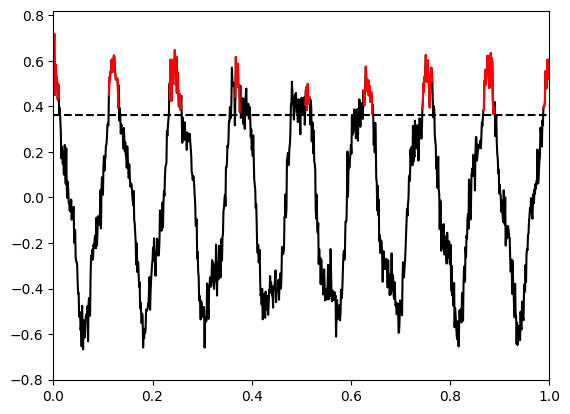

In [ ]:
signal = sig3
time = time
threshold = np.mean(sig3) + 1*np.std(sig3)

# your code goes here

idx = np.where(signal>threshold)[0]
transition = np.where(np.diff(idx)>1)[0]

start = np.concatenate([[idx[0]], idx[transition+1]])
end = np.concat([idx[transition], [idx[-1]]])
duration = end-start + 1

srate = int(1/np.diff(time)[0])
start = start[duration>=0.01*srate]
end = end[duration>=0.01*srate]




# modify the code below to add the asked plots
plt.plot(time, signal,'k')
plt.plot([time[0], time[-1]], threshold*np.ones(2),'--k')

for i in range(len(start)):
  plt.plot(time[start[i]:end[i]], signal[start[i]:end[i]],'r')

plt.xlim([0,1])
plt.show()



## Exercise 4:

As we saw above, the function np.diff can be used to compute the difference between consecutive values in an array. So, for an array `arr`, `np.diff(arr)` is equivalent to: `arr[1:]-arr[0:]`. In a way, this quantity is related to the discrete derivative, and hence name diff, from differential.

```
print(np.diff([1, 3, 4, 10]))
[2 1 6]
```

As you might have learned in Calculus, the differential can be used to find local minima and local maxima in an array (inflexion points). Of course, because in a computer values are stored in a discrete way, an inflection point of an array `arr` can be found not by finding where `np.diff(arr) == 0`, but where `np.diff(arr)` changes from positive to negative.

Use the `np.diff` function to find all the peaks of the 8 Hz component found in the previous exercise.

Before you start, also check the function `np.sign`.


[2 1 6]


array([ 1,  1, -1])